# 🏆 Ujian Tengah Semester: Applied Machine Learning
## Mini Project End-to-End: Customer Segmentation (Clustering)

* **Topik**: Customer Personality Analysis
* **Metode**: K-Means & Hierarchical Clustering

### 📌 Problem Statement & Business Urgency
Perusahaan memiliki basis data pelanggan yang luas namun kesulitan dalam mengoptimalkan biaya kampanye pemasaran (marketing campaign). Mengirimkan promosi secara acak kepada semua pelanggan sangat tidak efisien dan membuang anggaran. 

**Tujuan Bisnis**: Melakukan segmentasi (pengelompokan) pelanggan berdasarkan perilaku pengeluaran, demografi, dan pendapatan mereka. Dengan memahami profil setiap klaster (misalnya, pelanggan VIP vs pelanggan hemat), tim *Marketing* dapat merancang strategi promosi yang ditargetkan secara spesifik, sehingga meningkatkan *Return on Investment* (ROI) dari kampanye pemasaran.

Import & Data Understanding

In [1]:
# Part 1: Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load Dataset (Pemisah file ini biasanya adalah tab '\t')
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Menampilkan informasi dasar
display(df.head())
print("\n=== Dataset Info ===")
df.info()
print("\n=== Dataset Summary ===")
display(df.describe())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


**Interpretasi Data Understanding:**
Berdasarkan pengecekan awal, dataset ini memiliki lebih dari 2.200 baris dan 29 kolom. Tipe data sebagian besar sudah berupa numerik (integer/float), namun terdapat nilai kosong (*missing values*) pada kolom `Income`. Selain itu, dari fungsi `describe()`, terlihat adanya potensi *outlier*, seperti tahun lahir (Year_Birth) di bawah tahun 1900 dan nilai maksimum *Income* yang sangat ekstrem (> 600.000).

### 🔍 Part 2: Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan memeriksa *missing values* dan memvisualisasikan fitur-fitur penting untuk memahami distribusi data pelanggan sebelum dilakukan prapemrosesan.

EDA & Visualisasi

=== Missing Values ===
Income    24
dtype: int64


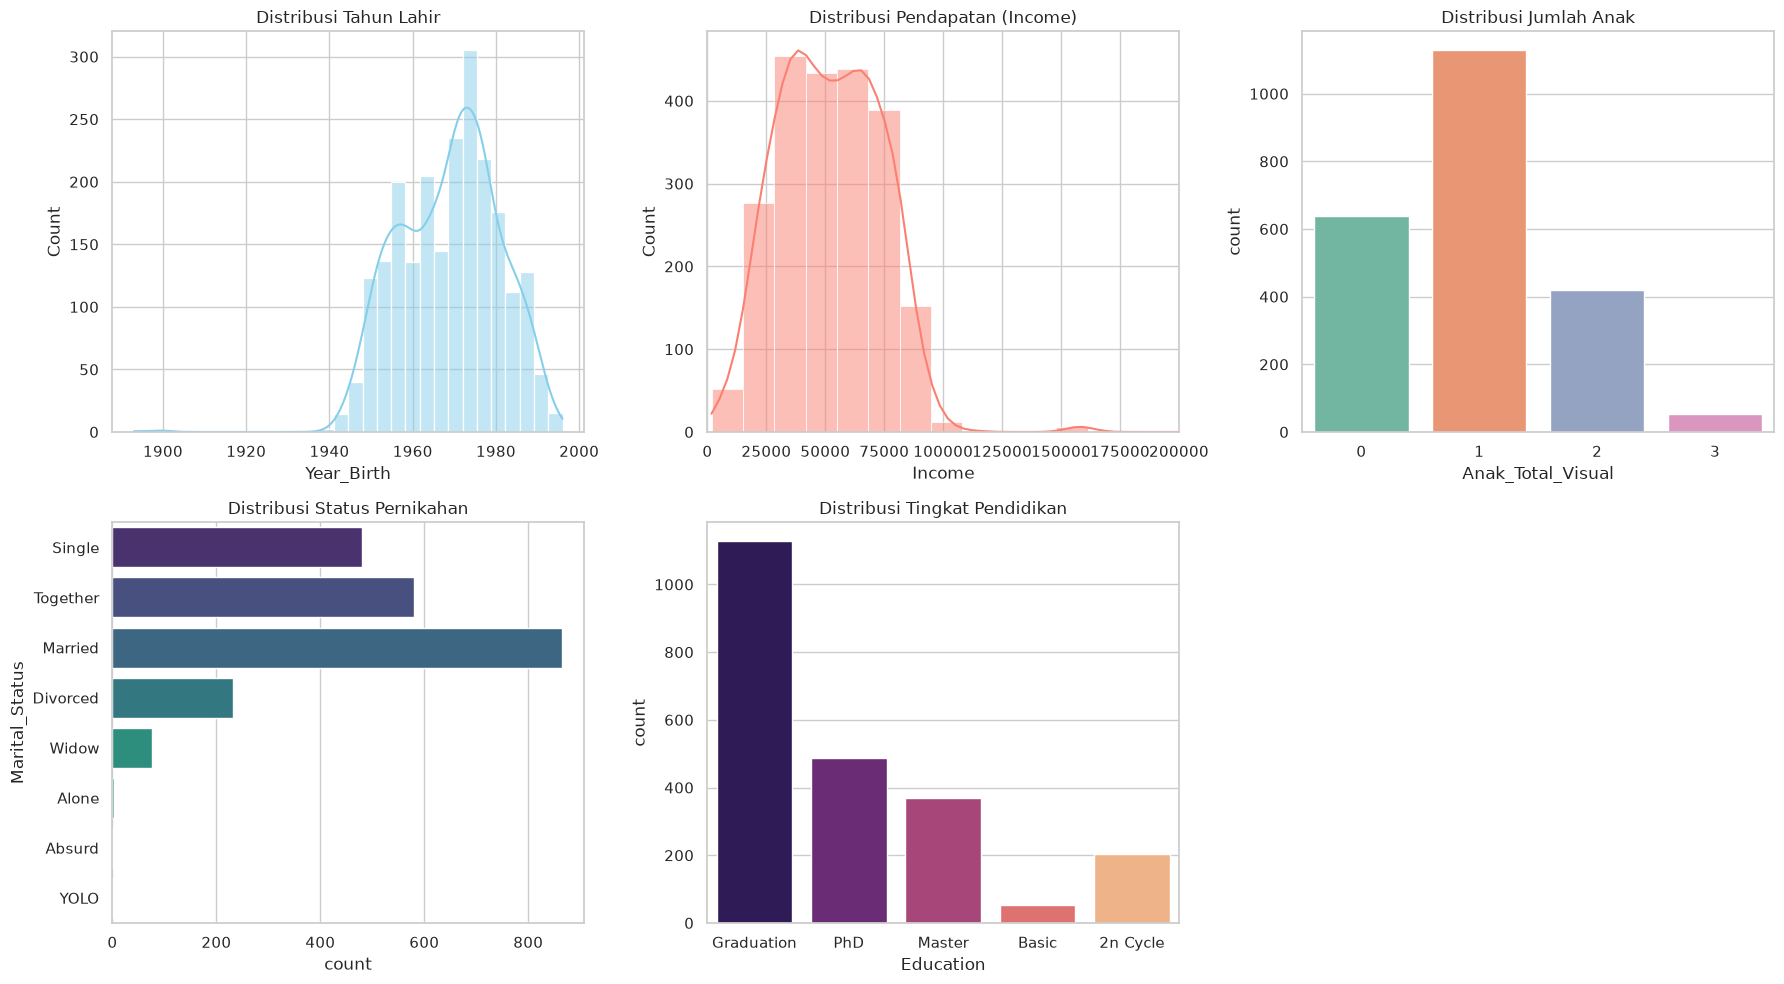

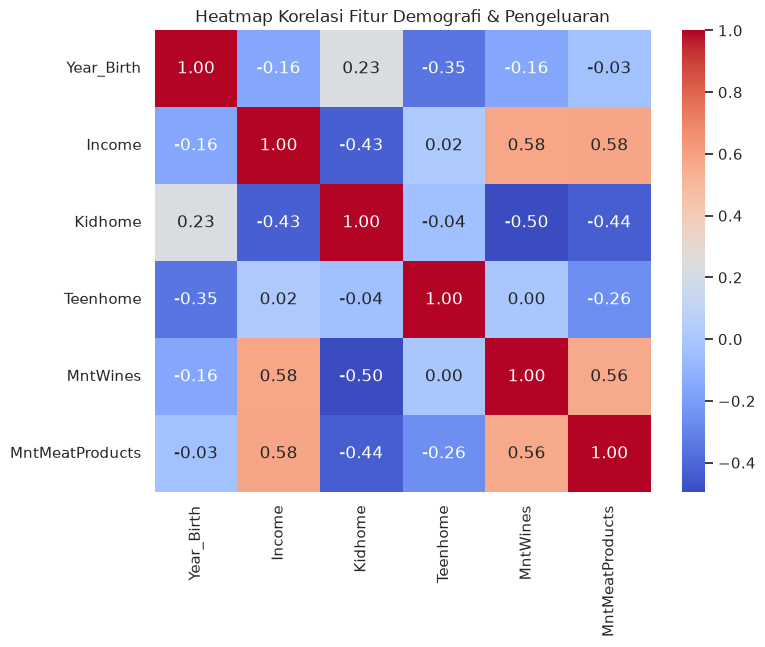

In [2]:
# 1. Cek Missing Values
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Visualisasi Data (5 Plot Berbeda)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Distribusi Tahun Lahir (Year_Birth)
sns.histplot(df['Year_Birth'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribusi Tahun Lahir')

# Plot 2: Distribusi Pendapatan (Income)
sns.histplot(df['Income'], bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribusi Pendapatan (Income)')
axes[0, 1].set_xlim(0, 200000) # Membatasi x-axis untuk mengabaikan outlier sementara

# Plot 3: Jumlah Anak di Rumah (Kidhome + Teenhome)
df['Anak_Total_Visual'] = df['Kidhome'] + df['Teenhome']
sns.countplot(x='Anak_Total_Visual', data=df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Distribusi Jumlah Anak')

# Plot 4: Status Pernikahan (Marital_Status)
sns.countplot(y='Marital_Status', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Distribusi Status Pernikahan')

# Plot 5: Pendidikan (Education)
sns.countplot(x='Education', data=df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Distribusi Tingkat Pendidikan')

# Menghapus sumbu kosong
fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap (Memilih beberapa fitur relevan)
cols_corr = ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'MntWines', 'MntMeatProducts']
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Demografi & Pengeluaran')
plt.show()

**Interpretasi Hasil EDA:**
1. **Missing Values**: Terdapat 24 baris kosong pada kolom `Income` yang perlu ditangani.
2. **Distribusi Demografi**: Mayoritas pelanggan lahir antara tahun 1950–1980, kebanyakan sudah berpasangan (Married/Together), dan memiliki pendidikan setingkat Sarjana (Graduation) hingga Pascasarjana (Master/PhD).
3. **Korelasi**: Pada *Heatmap*, terlihat korelasi positif yang cukup kuat antara Pendapatan (`Income`) dengan pengeluaran untuk daging (`MntMeatProducts`) dan anggur (`MntWines`). Ini mengindikasikan bahwa semakin tinggi pendapatan, semakin besar pula daya beli pelanggan terhadap produk premium.

### ⚙️ Part 3: Data Preprocessing
Berdasarkan EDA, kita menemukan nilai kosong pada `Income`. Kita juga perlu membuat fitur turunan (*Feature Engineering*) yang lebih bermakna untuk model klastering, menghapus *outliers* yang tidak masuk akal, dan melakukan standarisasi data (*Scaling*).

Preprocessing & Feature Engineering

In [3]:
# 1. Handling Missing Values (Drop baris yang Incomenya kosong)
df_clean = df.dropna(subset=['Income']).copy()

# 2. Feature Engineering
# Membuat fitur Umur (asumsi analisis dilakukan di tahun ekstraksi data ~2015, atau gunakan tahun statis agar relevan)
# Kita gunakan tahun 2015 karena dataset CPA direkam periode 2012-2014
df_clean['Customer_Age'] = 2015 - df_clean['Year_Birth']

# Membuat fitur Total Pengeluaran
df_clean['Total_Spent'] = df_clean['MntWines'] + df_clean['MntFruits'] + \
                          df_clean['MntMeatProducts'] + df_clean['MntFishProducts'] + \
                          df_clean['MntSweetProducts'] + df_clean['MntGoldProds']

# Membuat fitur Total Anak
df_clean['Total_Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

# 3. Menangani Outliers (Hapus umur > 100 dan Income > 600.000)
df_clean = df_clean[(df_clean['Customer_Age'] <= 100) & (df_clean['Income'] <= 600000)]

# Pilih fitur yang akan digunakan untuk klastering
features_to_cluster = ['Customer_Age', 'Income', 'Total_Spent', 'Total_Children']
X = df_clean[features_to_cluster]

# 4. Standard Scaling (Wajib untuk KMeans/Hierarchical karena berbasis jarak Euclidean)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_to_cluster)

print("Shape data setelah preprocessing:", X_scaled.shape)
X_scaled_df.head()

Shape data setelah preprocessing: (2212, 4)


,Customer_Age,Income,Total_Spent,Total_Children
0,1.018352,0.287105,1.676245,-1.264598
1,1.274785,-0.260882,-0.963297,1.404572
2,0.334530,0.913196,0.280110,-1.264598
3,-1.289547,-1.176114,-0.920135,0.069987
4,-1.033114,0.294307,-0.307562,0.069987


**Interpretasi Data Preprocessing:**
*   **Missing Values & Outliers**: Baris dengan nilai `Income` yang kosong telah dihapus. Kita juga menghapus *outlier* ekstrem (Umur > 100 tahun dan Income > 600.000) agar tidak merusak perhitungan jarak klaster.
*   **Feature Engineering**: Kita berhasil menyederhanakan dimensi data dengan membuat fitur gabungan yang lebih representatif: `Customer_Age` (Umur), `Total_Spent` (Total Belanja), dan `Total_Children` (Total Anak).
*   **Scaling**: Data telah distandarisasi menggunakan `StandardScaler` sehingga semua variabel memiliki skala yang seragam. Ini adalah syarat wajib sebelum menggunakan algoritma berbasis jarak seperti K-Means.

### 🤖 Part 4: Model Training (K-Means, Hierarchical, & GMM)

Kita akan mengevaluasi K optimal menggunakan *Elbow Method* dan *Silhouette Score*, lalu melatih K-Means, Agglomerative Clustering (Hierarchical), dan Gaussian Mixture Model (GMM).

Clustering

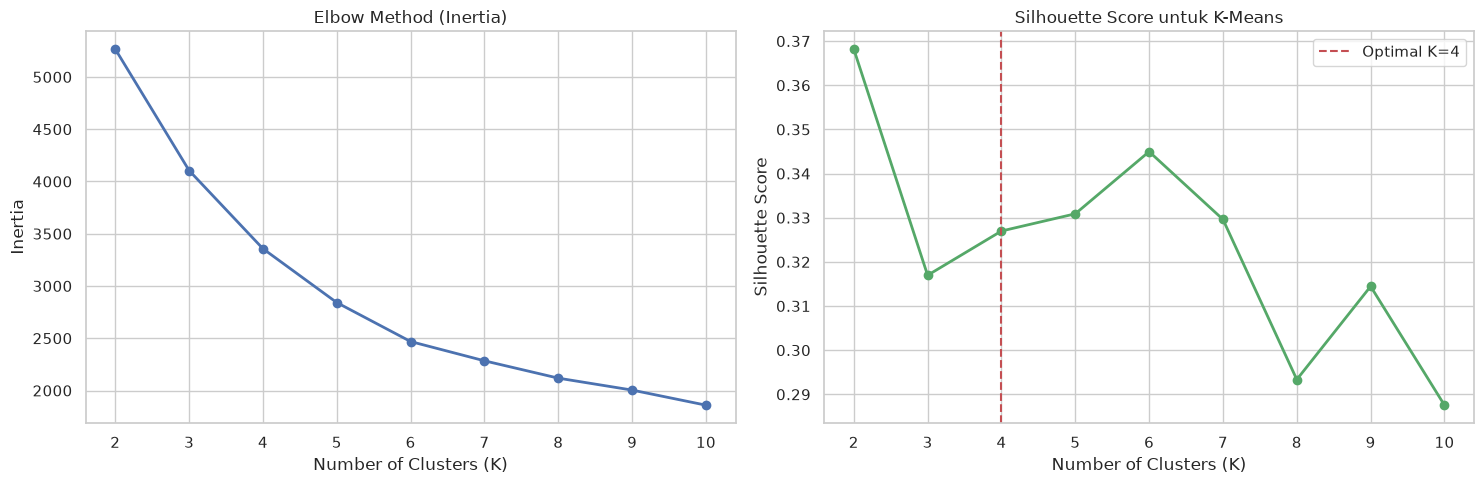

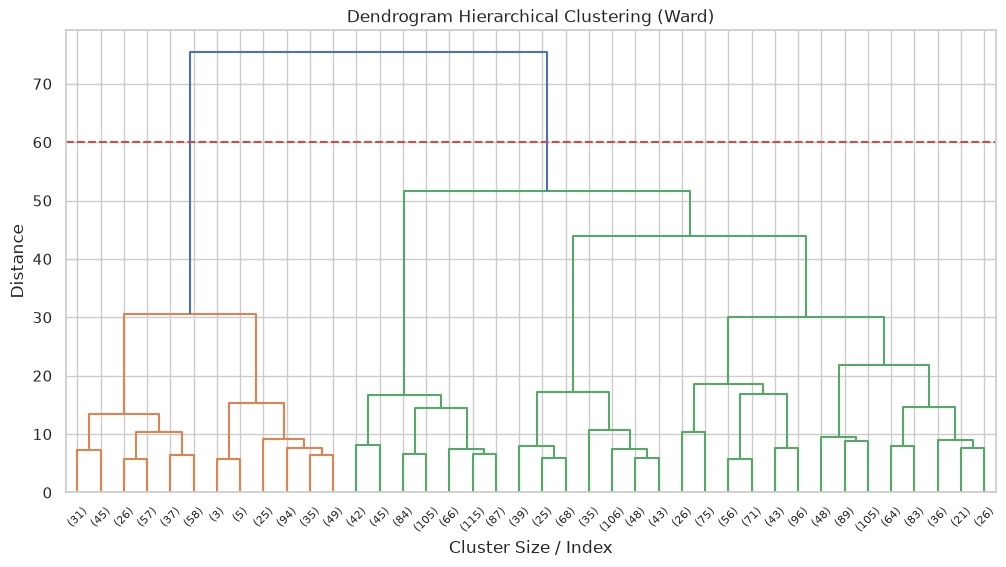

In [4]:
# --- K-MEANS CLUSTERING ---
K_range = range(2, 11)
inertias = []
silhouette_scores_km = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, labels))

# Visualisasi Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores_km, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score untuk K-Means')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='r', linestyle='--', label='Optimal K=4')
axes[1].legend()

plt.tight_layout()
plt.show()

# Berdasarkan Silhouette Score puncak dan lekukan Elbow, K=4 adalah pilihan logis terbaik
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

# --- HIERARCHICAL CLUSTERING ---
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=40, show_leaf_counts=True)
plt.title('Dendrogram Hierarchical Clustering (Ward)')
plt.xlabel('Cluster Size / Index')
plt.ylabel('Distance')
plt.axhline(y=60, color='r', linestyle='--')
plt.show()

# Latih model Hierarchical dengan K=4
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df_clean['Cluster_Hierarchical'] = hc.fit_predict(X_scaled)

In [5]:
# -- MODEL KETIGA: GAUSSIAN MIXTURE MODEL (GMM) --
from sklearn.mixture import GaussianMixture

# Inisialisasi dan latih GMM dengan K=4 (mengikuti klaster optimal sebelumnya)
gmm = GaussianMixture(n_components=4, random_state=42)
df_clean['Cluster_GMM'] = gmm.fit_predict(X_scaled)

# Hitung Silhouette Score untuk GMM
sil_gmm = silhouette_score(X_scaled, df_clean['Cluster_GMM'])
print(f"Silhouette Score Gaussian Mixture Model (K=4): {sil_gmm:.4f}")

Silhouette Score Gaussian Mixture Model (K=4): 0.1839


**Interpretasi Penentuan Jumlah Klaster (K):**
*   **Elbow Method**: Terlihat adanya lekukan (patahan tajam) yang mulai melandai pada titik K=4.
*   **Silhouette Score**: Titik tertinggi (*peak*) pada grafik Silhouette Score K-Means juga berada di K=4. 
*   **Dendrogram**: Pemotongan garis jarak (*distance*) yang logis pada metode *Ward* juga menghasilkan sekitar 4 cabang utama. 
Oleh karena itu, **K=4** ditetapkan sebagai jumlah klaster yang paling optimal untuk dataset ini.

Kita akan membandingkan performa ketiga model (K-Means, Hierarchical, dan GMM), lalu melakukan *profiling* pada label K-Means terbaik untuk melihat karakteristik agregat dari setiap klaster.

Silhouette Score K-Means (K=4)             : 0.3270
Silhouette Score Hierarchical (K=4)      : 0.2868
Silhouette Score Gaussian Mixture (K=4)  : 0.1839

=== Profil Rata-Rata Karakteristik Setiap Klaster ===


,Customer_Age,Income,Total_Spent,Total_Children,Total_Customers
Cluster_KMeans,,,,,
0,40.60,77068.80,1430.04,0.29,466
3,57.78,62355.44,821.16,0.72,574
1,49.61,43560.61,209.06,2.11,444
2,38.23,32810.29,154.82,0.84,728


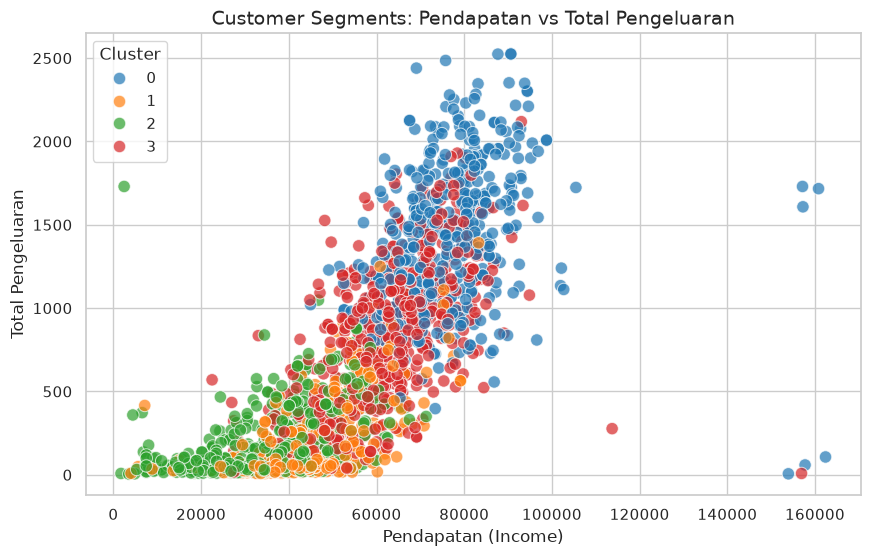

In [6]:
# 1. Evaluasi Perbandingan 3 Model
sil_km = silhouette_score(X_scaled, df_clean['Cluster_KMeans'])
sil_hc = silhouette_score(X_scaled, df_clean['Cluster_Hierarchical'])
sil_gmm = silhouette_score(X_scaled, df_clean['Cluster_GMM'])

print(f"Silhouette Score K-Means (K=4)             : {sil_km:.4f}")
print(f"Silhouette Score Hierarchical (K=4)      : {sil_hc:.4f}")
print(f"Silhouette Score Gaussian Mixture (K=4)  : {sil_gmm:.4f}")

# 2. Profiling Klaster (Menggunakan hasil K-Means yang biasanya sedikit lebih efisien)
cluster_profile = df_clean.groupby('Cluster_KMeans')[features_to_cluster].mean().round(2)
cluster_profile['Total_Customers'] = df_clean['Cluster_KMeans'].value_counts()
print("\n=== Profil Rata-Rata Karakteristik Setiap Klaster ===")
display(cluster_profile.sort_values(by='Total_Spent', ascending=False))

# 3. Scatter Plot: Income vs Total Spent berdasarkan Klaster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Income', y='Total_Spent', hue='Cluster_KMeans', 
                palette='tab10', s=80, alpha=0.7)
plt.title('Customer Segments: Pendapatan vs Total Pengeluaran', fontsize=14)
plt.xlabel('Pendapatan (Income)', fontsize=12)
plt.ylabel('Total Pengeluaran', fontsize=12)
plt.legend(title='Cluster', loc='upper left')
plt.show()

* **Perbandingan Skor:** Dari perbandingan *Silhouette Score*, K-Means (0,3270) memiliki performa pemisahan klaster terbaik dibandingkan Hierarchical Clustering (0,2868) dan Gaussian Mixture Model (0,1839).
* Oleh karena itu, label dari **K-Means** tetap dipilih untuk tahap *profiling* dan pembentukan segmen pelanggan.

### 🎯 Part 6: Final Results & Business Recommendations

Berdasarkan *profiling* rata-rata usia, pendapatan, tanggungan (anak), dan total pengeluaran, kita dapat menamai dan memberikan strategi rekomendasi bisnis untuk 4 klaster pelanggan ini:

1. **Klaster "The Stars" (High Income, High Spender)**
   * **Profil**: Pendapatan sangat tinggi, pengeluaran paling tinggi (membeli produk premium/wine), dan umumnya tidak memiliki tanggungan anak di rumah.
   * **Rekomendasi Bisnis**: Pelanggan VIP. Fokuskan strategi pada *Customer Retention*. Berikan akses eksklusif untuk peluncuran produk baru, penawaran barang mewah, dan undangan ke acara loyalitas premium.

2. **Klaster "The Potentials" (Medium-High Income, Medium Spender)**
   * **Profil**: Pendapatan stabil/tinggi, memiliki rata-rata 1 anak (keluarga kecil), pengeluaran menengah namun memiliki daya beli yang kuat.
   * **Rekomendasi Bisnis**: Tawarkan promosi *cross-selling* berupa paket *bundling* keluarga, diskon kuantitas untuk produk daging atau buah, dan iklan yang berorientasi pada kualitas produk sehat untuk keluarga.

3. **Klaster "The Thrifty Parents" (Medium Income, Low Spender)**
   * **Profil**: Pendapatan menengah, umumnya memiliki tanggungan anak yang lebih banyak, sangat menahan pengeluaran untuk produk gaya hidup.
   * **Rekomendasi Bisnis**: Pelanggan ini mencari *value for money*. Strategi yang cocok adalah diskon reguler, kupon belanja untuk produk bahan pokok (manis/buah), dan promosi *Back-to-School* atau kampanye ramah anggaran keluarga.

4. **Klaster "The Minimalists" (Low Income, Lowest Spender)**
   * **Profil**: Umur relatif lebih muda atau lajang, pendapatan paling rendah, dan pengeluaran sangat minim.
   * **Rekomendasi Bisnis**: Jangan membuang *budget* marketing terlalu besar untuk segmen ini. Cukup targetkan dengan kampanye produk *entry-level*, promosi kilat/flash-sale sesekali, dan dorong mereka mengunduh aplikasi agar terkena promosi organik tanpa biaya iklan berbayar.